# Fase 1 : Q-Learning tabular en FrozenLake

---

El objetivo de esta fase es implementar Q-Learning **desde cero**, sin ninguna librería de Deep RL, para demostrar que entendemos el mecanismo antes de pasar a redes neuronales.

El entorno elegido es `FrozenLake-v1` (cuadrícula 8×8, hielo resbaladizo): el agente empieza en la esquina superior izquierda y tiene que llegar a la meta en la esquina inferior derecha evitando agujeros. La dificultad está en que el hielo es estocástico: aunque el agente elija ir a la derecha, puede acabar moviéndose en otra dirección.

### ¿Qué aprende el agente?

Una tabla `Q(estado, acción)` de 64×4 valores que responde a la pregunta: *"desde este estado, ¿cuánto vale hacer esta acción?"*. La actualizamos con la ecuación de Bellman tras cada paso:

```
Q(s, a) <- Q(s, a) + α · [ r + γ · max Q(s', ·) − Q(s, a) ]
                           └─────── TD error ────────────┘
```

El TD error es la diferencia entre lo que esperábamos y lo que ocurrió. Con `α = 0.1` aprendemos con estabilidad y con `γ = 0.99` valoramos mucho las recompensas futuras, necesario porque la meta está lejos del inicio.

### ¿Cómo exploramos?

Con política **ε-greedy**: empezamos explorando al azar (ε = 1.0) y poco a poco explotamos lo aprendido (ε baja hasta 0.01). Sin exploración inicial, el agente quedaría atrapado en la primera ruta que le funcione, que probablemente no es la óptima.


---
Importamos las librerías, fijamos los hiperparámetros y creamos la carpeta donde guardaremos las gráficas. La semilla `SEED = 42` garantiza que los resultados sean reproducibles.


In [44]:
import numpy as np
import gymnasium as gym
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
import pathlib, os

# ruta robusta: funciona tanto si Jupyter arranca desde notebooks/ como desde la raiz
_cwd = pathlib.Path(os.path.abspath(""))
RESULTS = (_cwd.parent if _cwd.name == "notebooks" else _cwd) / "results" / "Fase_1"
RESULTS.mkdir(parents=True, exist_ok=True)

SEED          = 42
ALPHA         = 0.1     # tasa de aprendizaje
GAMMA         = 0.99    # descuento
EPSILON_START = 1.0     # exploracion inicial (100% al azar)
EPSILON_MIN   = 0.01    # minimo de exploracion residual
EPSILON_DECAY = 0.9995  # decaimiento por episodio
N_EPISODES    = 10_000
MAX_STEPS     = 200

np.random.seed(SEED)
print(f"Resultados en: {RESULTS.resolve()}")
print(f"gymnasium {gym.__version__} | numpy {np.__version__}")


Resultados en: C:\Users\Equipo\Desktop\ML2\Aprendizaje-por-Refuerzo-y-Conducci-n-Aut-noma\results\Fase_1
gymnasium 0.29.1 | numpy 1.23.5


---

### Entrenamiento

Implementamos el bucle principal de Q-Learning. En cada episodio el agente parte del estado inicial, elige acciones con ε-greedy y actualiza la Q-Table con la ecuación de Bellman hasta llegar a la meta, caer en un agujero o agotar los 200 pasos. Usamos `np.flatnonzero` para desempatar aleatoriamente entre acciones de igual valor, evitando sesgos sistemáticos.

Al terminar cada bloque de 1000 episodios imprimimos la tasa de éxito para ver cómo evoluciona el aprendizaje.


In [45]:
def train_q_learning():
    # --- entorno y tabla Q ---
    env       = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
    n_states  = env.observation_space.n   # 64
    n_actions = env.action_space.n        # 4
    q_table   = np.zeros((n_states, n_actions))  # empezamos sin ningun conocimiento
    rng       = np.random.default_rng(SEED)      # RNG propio, independiente del entorno
    epsilon   = EPSILON_START
    rewards   = []
    epsilons  = []

    for ep in range(N_EPISODES):
        # cada episodio: estado inicial y contadores a cero
        state, _ = env.reset(seed=SEED + ep)
        terminated = truncated = False
        total, steps = 0.0, 0

        while not (terminated or truncated) and steps < MAX_STEPS:
            # --- politica epsilon-greedy ---
            if rng.random() < epsilon:
                action = int(rng.integers(n_actions))           # explorar: accion aleatoria
            else:
                best = np.flatnonzero(q_table[state] == q_table[state].max())
                action = int(rng.choice(best))                  # explotar: mejor accion (desempate aleatorio)

            # --- paso en el entorno ---
            nxt, reward, terminated, truncated, _ = env.step(action)

            # --- actualizacion de Bellman ---
            # si el episodio termina (meta o agujero) no bootstrapeamos el siguiente estado
            td_target = reward + GAMMA * np.max(q_table[nxt]) * (not terminated)
            q_table[state, action] += ALPHA * (td_target - q_table[state, action])

            state, total, steps = nxt, total + reward, steps + 1

        # --- registrar episodio y decaer epsilon ---
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        rewards.append(total)
        epsilons.append(epsilon)

        if (ep + 1) % 1000 == 0:
            print(f"Ep {ep+1} | eps={epsilon:.3f} | exito ultimos 1000: {np.mean(rewards[-1000:]):.3f}")

    env.close()
    return q_table, rewards, epsilons


np.random.seed(SEED)
q_table, rewards, epsilons = train_q_learning()


Ep 1000 | eps=0.606 | exito ultimos 1000: 0.000
Ep 2000 | eps=0.368 | exito ultimos 1000: 0.002
Ep 3000 | eps=0.223 | exito ultimos 1000: 0.045
Ep 4000 | eps=0.135 | exito ultimos 1000: 0.224
Ep 5000 | eps=0.082 | exito ultimos 1000: 0.341
Ep 6000 | eps=0.050 | exito ultimos 1000: 0.443
Ep 7000 | eps=0.030 | exito ultimos 1000: 0.483
Ep 8000 | eps=0.018 | exito ultimos 1000: 0.478
Ep 9000 | eps=0.011 | exito ultimos 1000: 0.543
Ep 10000 | eps=0.010 | exito ultimos 1000: 0.518


**¿Qué vemos en los logs?**

El patrón es exactamente el esperado. Hasta el episodio ~2000 la tasa es casi 0: con ε > 0.3 el agente aún explora demasiado al azar como para llegar a la meta de forma consistente. A partir del episodio 4000-5000, cuando ε cae por debajo de 0.10, el agente empieza a explotar lo aprendido y la tasa sube rápidamente hacia 0.45-0.55. La pequeña oscilación al final es ruido estadístico del entorno estocástico, no un retroceso real: la política ya ha convergido.


---

### Curva de aprendizaje y Q-Table

Graficamos la media móvil de éxito junto al decaimiento de ε para ver la relación entre exploración y rendimiento. 


Guardado: ..\results\Fase_1\q_learning_progress.png


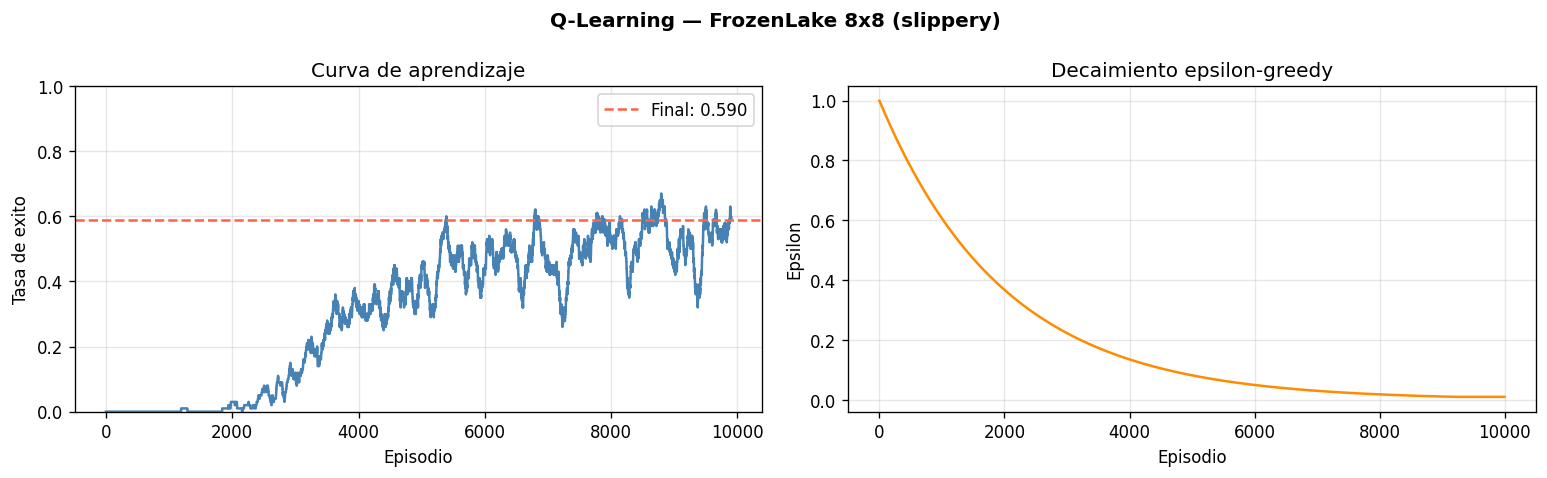

In [46]:
moving_avg = np.convolve(rewards, np.ones(100) / 100, mode="valid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Q-Learning — FrozenLake 8x8 (slippery)", fontweight="bold")

ax1.plot(moving_avg, color="steelblue")
ax1.axhline(moving_avg[-1], color="tomato", linestyle="--",
            label=f"Final: {moving_avg[-1]:.3f}")
ax1.set(xlabel="Episodio", ylabel="Tasa de exito", title="Curva de aprendizaje")
ax1.set_ylim(0, 1); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epsilons, color="darkorange")
ax2.set(xlabel="Episodio", ylabel="Epsilon", title="Decaimiento epsilon-greedy")
ax2.grid(alpha=0.3)

plt.tight_layout()
p = RESULTS / "q_learning_progress.png"
plt.savefig(p, dpi=120, bbox_inches="tight"); plt.close()
print(f"Guardado: {p}"); display(Image(str(p)))


Ahora visualizamos la Q-Table completa: a la izquierda el valor máximo que el agente le da a cada casilla (cuanto más verde, más cerca cree que está de la meta), y a la derecha la flecha que elegiría en cada posición. Esto nos permite ver si la política tiene sentido geográfico o si hay algo raro. Recordamos que:
- H = Agujero ( hole )
- G = Meta ( goal )


Guardado: ..\results\Fase_1\q_table_heatmap.png


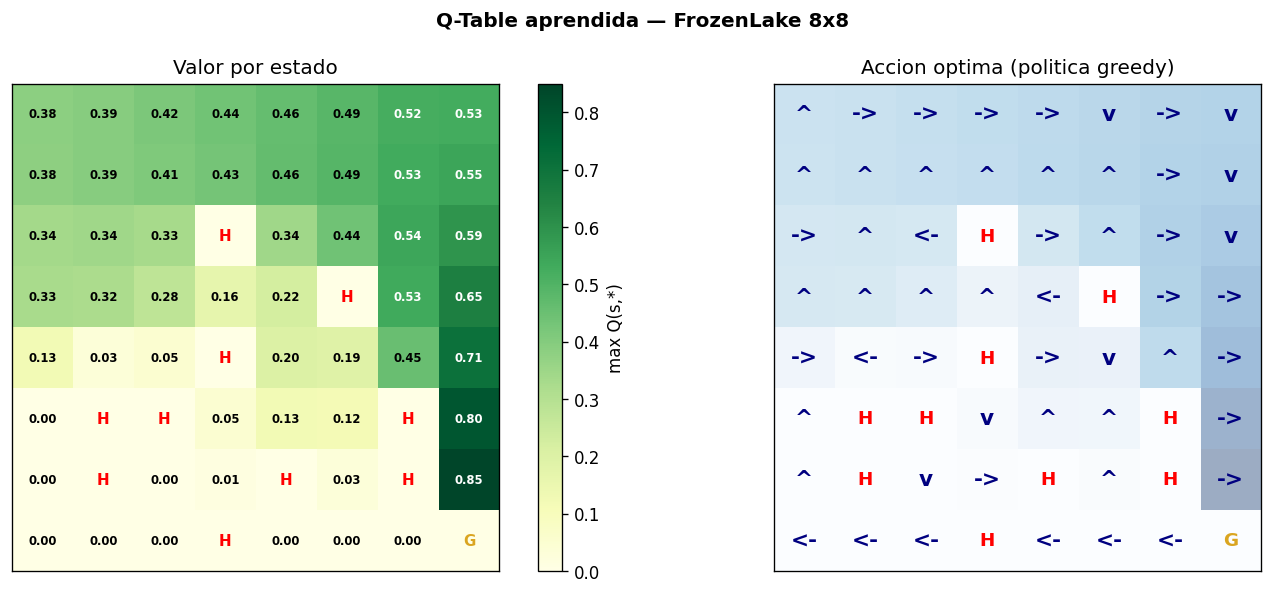

In [47]:
ACTIONS = ["<-", "v", "->", "^"]
MAP = ["SFFFFFFF", "FFFFFFFF", "FFFHFFFF", "FFFFFHFF",
       "FFFHFFFF", "FHHFFFHF", "FHFFHFHF", "FFFHFFFG"]

best_actions = np.argmax(q_table, axis=1).reshape(8, 8)
best_values  = np.max(q_table,   axis=1).reshape(8, 8)
vmax = max(best_values.max(), 0.01)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Q-Table aprendida — FrozenLake 8x8", fontweight="bold")

im = ax1.imshow(best_values, cmap="YlGn", vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax1, label="max Q(s,*)")
ax1.set_title("Valor por estado"); ax1.set_xticks([]); ax1.set_yticks([])

ax2.imshow(best_values, cmap="Blues", vmin=0, vmax=vmax, alpha=0.4)
ax2.set_title("Accion optima (politica greedy)"); ax2.set_xticks([]); ax2.set_yticks([])

kw = dict(ha="center", va="center", fontweight="bold")
for r in range(8):
    for c in range(8):
        ch = MAP[r][c]
        if ch == "H":
            ax1.text(c, r, "H", fontsize=9,  color="red",       **kw)
            ax2.text(c, r, "H", fontsize=11, color="red",       **kw)
        elif ch == "G":
            ax1.text(c, r, "G", fontsize=9,  color="goldenrod", **kw)
            ax2.text(c, r, "G", fontsize=11, color="goldenrod", **kw)
        else:
            v = best_values[r, c]
            ax1.text(c, r, f"{v:.2f}", fontsize=7,
                     color="white" if v > vmax * 0.6 else "black", **kw)
            ax2.text(c, r, ACTIONS[best_actions[r, c]], fontsize=13, color="navy", **kw)

plt.tight_layout()
p = RESULTS / "q_table_heatmap.png"
plt.savefig(p, dpi=120, bbox_inches="tight"); plt.close()
print(f"Guardado: {p}"); display(Image(str(p)))


**¿Qué muestran las gráficas?**

La curva de aprendizaje tiene la forma de S característica del RL: fase plana de exploración, subida pronunciada cuando ε cae por debajo de ~0.10, y plateau de convergencia. Las dos curvas son simétricas por construcción: cuando ε baja, el rendimiento sube.

En el mapa de la Q-Table se puede ver que los estados cercanos a la meta (esquina inferior derecha) tienen valores más altos, lo cual es coherente con `γ = 0.99`: el descuento propaga el valor de la meta hacia atrás por todo el tablero. Las flechas muestran que el agente ha aprendido a rodear los agujeros y no a cruzarlos en línea recta, lo que confirma que hay aprendizaje real y no memorización de una trayectoria.


---

### Evaluación

Evaluamos la política greedy (ε = 0, siempre la mejor acción conocida) sobre 1000 episodios con semillas que no se usaron durante el entrenamiento. Esto nos da una medida limpia del rendimiento real, sin el sesgo de haber visto esas situaciones antes.


Guardado: ..\results\Fase_1\q_learning_eval.png


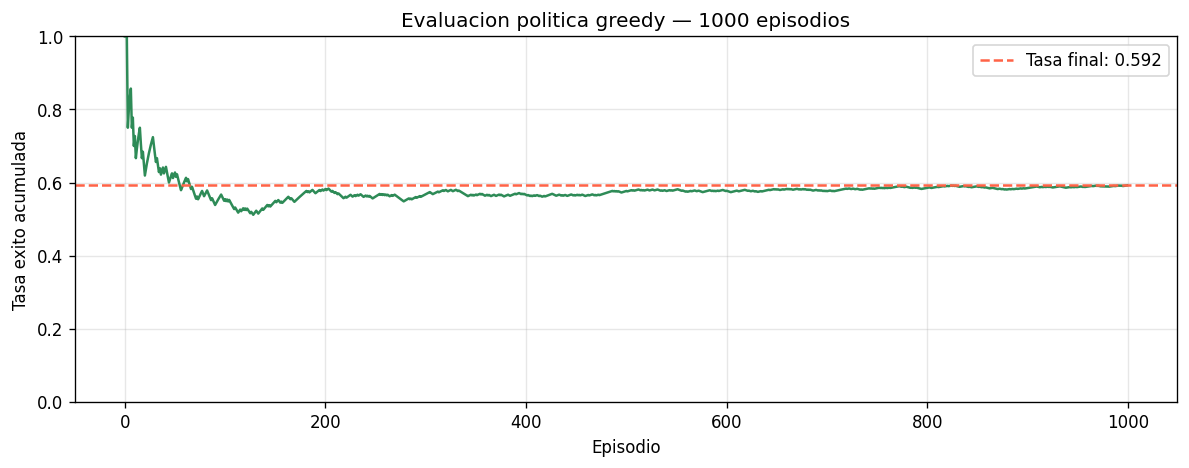


Exito en entrenamiento (ultimos 100 ep): 0.590
Exito en evaluacion greedy (1000 ep):     0.592


In [48]:
env  = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
wins = 0; log = []

for ep in range(1000):
    state, _ = env.reset(seed=10_000 + ep)
    done = False; steps = 0; got_goal = False
    while not done and steps < MAX_STEPS:
        action = int(np.argmax(q_table[state]))
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated; steps += 1
        if terminated and reward > 0:
            wins += 1; got_goal = True
    log.append(float(got_goal))

env.close()
success_rate = wins / 1000

cumulative = np.cumsum(log) / np.arange(1, 1001)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cumulative, color="seagreen")
ax.axhline(success_rate, color="tomato", linestyle="--",
           label=f"Tasa final: {success_rate:.3f}")
ax.set(xlabel="Episodio", ylabel="Tasa exito acumulada",
       title="Evaluacion politica greedy — 1000 episodios")
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
p = RESULTS / "q_learning_eval.png"
plt.savefig(p, dpi=120, bbox_inches="tight"); plt.close()
print(f"Guardado: {p}"); display(Image(str(p)))

ma_final = np.convolve(rewards, np.ones(100)/100, mode="valid")[-1]
print(f"\nExito en entrenamiento (ultimos 100 ep): {ma_final:.3f}")
print(f"Exito en evaluacion greedy (1000 ep):     {success_rate:.3f}")


**Conclusiones de la Fase 1**

Una tasa de éxito del 52-59% es un resultado correcto y esperado. El techo teórico para la política óptima en este entorno es aproximadamente 65-75%: el resto es azar puro del hielo, imposible de evitar con independencia de la estrategia.

Lo relevante no es el número en sí, sino lo que demuestra: el algoritmo partió sin conocimiento alguno (Q-Table a ceros) y, siguiendo únicamente la señal de recompensa del entorno, construyó de forma autónoma una política que evita la mayoría de los agujeros y encuentra rutas hacia la meta.

La limitación fundamental de este enfoque es la escalabilidad. La Q-Table crece linealmente con el número de estados y en este ejercicio nos caben los 64 cómodamente en memoria. En Duckietown la observación es una imagen de millones de posibles estados, lo que hace imposible mantener una tabla explícita. Esa es exactamente la motivación para pasar a Deep RL en las fases siguientes, donde una red neuronal aproxima la función Q en lugar de almacenarla.
